numpy matplotlib openpyxl pandas scipy intertools

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl

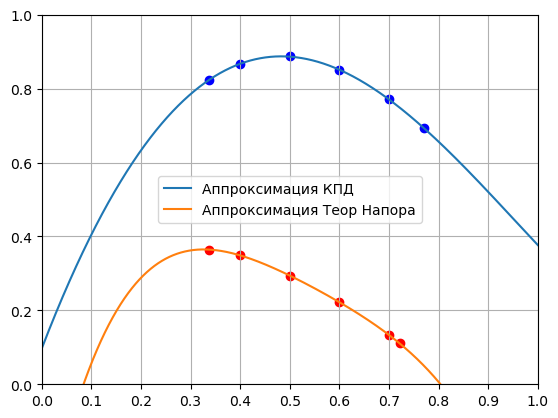

In [2]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [3]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха

In [4]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [5]:
d1_отн = 0.4
c_а1_отн = 0.7
c_a2_отн = 0.36
Hт_ср_отн = 0.4
H_т1 = 0.15
R_ср1 = 0.5
D_type = 'D_к_const'

# Первое приближение

In [6]:
# Ограничения

MAX_UK1 = 350.0            # Верхний предел окружной скорости 1-й ступени, м/с
MAX_CA_DROP = 12.0         # Максимально допустимое падение c_a между соседними ступенями, м/с
MIN_BLADE_HEIGHT = 20e-3   # Минимальная высота лопатки, м
MAX_D3_REL = 0.92          # Максимальный относительный диаметр втулки последней ступени

In [7]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_пол, Tа_полн):
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = np.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = np.cbrt((G_в * n**2)/(np.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return np.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * np.sqrt(R_в * T)) / (β * P * q)

def β_k_def(k):
    β = np.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))
    return(β)

def c_p_def(P_poln_Pa, T1_poln_K):
    """
    Находит c_p:
    P_poln_Pa: Давление на входе в Паскалях (Pa)
    T1_poln_K: Температура на входе в Кельвинах (K)
    """
    # Перевод входного давления из Па в бары для сопоставления с таблицей
    P_poln_bar = P_poln_Pa / 1e5
    
    # Получаем список уникальных давлений из таблицы (они уже в барах)
    available_pressures = df['p_bar'].unique()
    
    # 2. Поиск самого близкого давления в барах
    closest_p = available_pressures[np.abs(available_pressures - P_poln_bar).argmin()]
    
    # Фильтруем данные для выбранной изобары
    data_p = df[df['p_bar'] == closest_p].sort_values('T_K')
    
    # 3. Линейная интерполяция по температуре
    # np.interp(целевая_T, список_T_из_таблицы, список_cp_из_таблицы)
    cp_value = np.interp(T1_poln_K, data_p['T_K'], data_p['c_p'])
    
    return cp_value

def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return np.array(x_result), np.array(y_result)

def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

# Предзагрузка таблицы c_p один раз (вместо чтения CSV в каждой итерации model)
def _load_cp_table(csv_path='resources/air_param.csv'):
    data = np.genfromtxt(csv_path, delimiter=',', names=True, dtype=float, encoding='utf-8')
    p_grid = np.unique(data['p_bar'])
    t_grid = np.unique(data['T_K'])
    cp_grid = np.empty((p_grid.size, t_grid.size), dtype=np.float64)

    for ip, p_val in enumerate(p_grid):
        mask = data['p_bar'] == p_val
        t_row = data['T_K'][mask]
        cp_row = data['c_p'][mask]
        order = np.argsort(t_row)
        cp_grid[ip, :] = np.interp(t_grid, t_row[order], cp_row[order])

    return p_grid.astype(np.float64), t_grid.astype(np.float64), cp_grid.astype(np.float64)


P_GRID_BAR, T_GRID_K, CP_GRID = _load_cp_table()

def cp_lookup_array(p_pa_arr, t_k_arr):
    out = np.empty_like(t_k_arr, dtype=np.float64)
    for i in range(t_k_arr.shape[0]):
        p_bar = p_pa_arr[i] / 1e5
        best_idx = int(np.abs(P_GRID_BAR - p_bar).argmin())
        out[i] = np.interp(t_k_arr[i], T_GRID_K, CP_GRID[best_idx]) * 1000.0
    return out

In [8]:
# 1. Импорт и очистка данных
# skipinitialspace=True убирает пробелы после запятых в CSV
df = pd.read_csv('resources/air_param.csv', skipinitialspace=True)

# Очищаем названия колонок от случайных пробелов
df.columns = df.columns.str.strip()

# Принудительно переводим важные колонки в числа. 
# Ошибки (буквы) станут NaN, которые мы потом удалим.
cols_to_fix = ['p_bar', 'T_K', 'c_p']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

In [9]:
# Определим адиабатический КПД
η_пол = 0.90 # Политропический КПД компрессора из рис.1

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

#  Ожидаемый КПД
η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
π_к_полн_0 = π_к_полн
η_к_полн_0 = η_к_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k, R_в, Tа_полн)
a_кр_вых = a_кр_def(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
if U_k1 > MAX_UK1:
        print(f"U_k1 > максимально допустимой скорости")

# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)


π_ла_полн = π_к_полн / (σ_вх * σ_вых)
η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)

π_ла_полн_0 = π_ла_полн
η_ла_полн_0 = η_ла_полн

print(f"""
σ_вх * σ_вых = {σ_вх * σ_вых}
π_ла_полн = {π_ла_полн}
η_к_полн = {η_к_полн}
η_ла_полн = {η_ла_полн}
""")


σ_вх * σ_вых = 0.9871138474421737
π_ла_полн = 18.437589592284773
η_к_полн = 0.8338097173818555
η_ла_полн = 0.8535838734561604



In [10]:
U_k1_before = U_k1 * 100
number = 1
while True:
    # Осевая скорость на переферии РК
    c_а1 = c_real_def(U_k1, c_а1_отн)
    
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Пренебрегая теплообменом в трубках:
    T1_полн = Tа_полн


    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
    T2_полн = Tk_полн

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k, R_в, Tk_полн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)       
    ε_вых = ε_gdf(k, λ_вых)
    #  !!!!!!!!Перепроверить верность выражений в функции!

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн
    Pк_полн = Pа_полн * π_к_полн
    P2_полн = Pк_полн / σ_вых
    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = λ_def(c1, a_кр_вх)

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Плотность рабочего тела перед РК
    ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    loss_percenteg = 0.00001
    # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
    if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
        break
    else:
        U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
        number = number + 1 # Подсчет числа итераций
    

In [11]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = β_k_def(k)

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

In [12]:
# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

In [13]:
# Выбор формы проточной части лопаточного аппарата. 

if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d_n_отн = D_вт_n / D_к
    h_n = (1/2) * D_к * (1 - d_n_отн)

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
    d_n_отн = D_вт / D_к_n
    h_n = (1/2) * (D_к_n - D_вт)

else:
    # Dср = const
    
    D_ср = D_ср1
    D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
    D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
    h_n = (1/2)*(D_к_n - D_вт_n)
    d_n_отн = d1_отн

In [14]:
# Окружная скорость концов рабочих лопаток "средней" ступени:
ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
U_к_ср = (U_k1 + U_k2) / 2
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_к_ср**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
z = math.ceil(z)
N_stupeney = z

In [15]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_i_отн = []
Hт_i_отн = []

c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [16]:
Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)

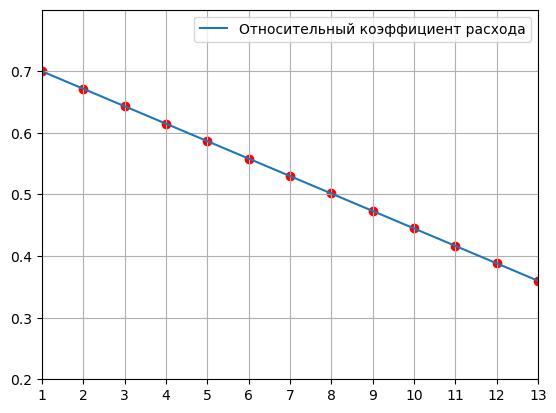

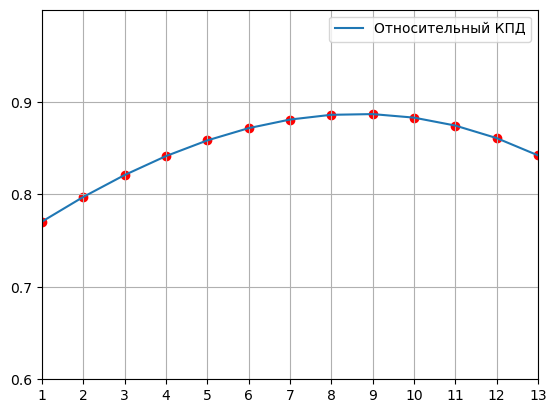

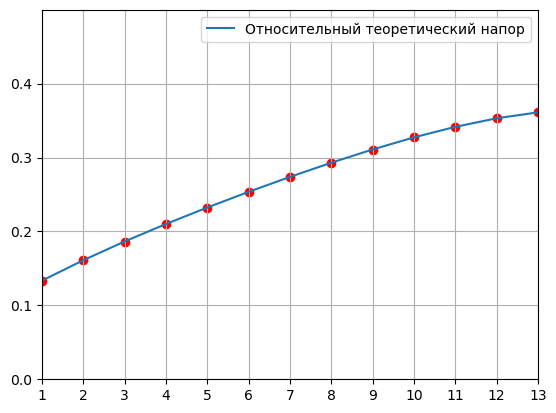

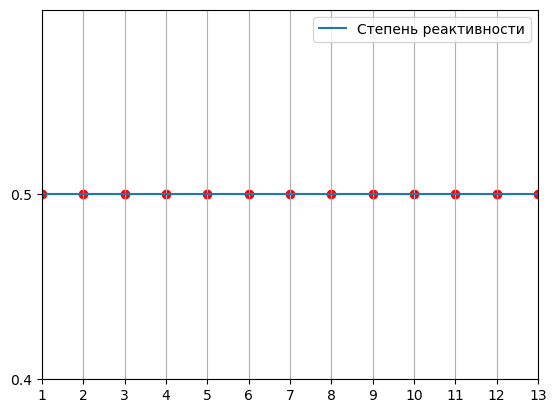

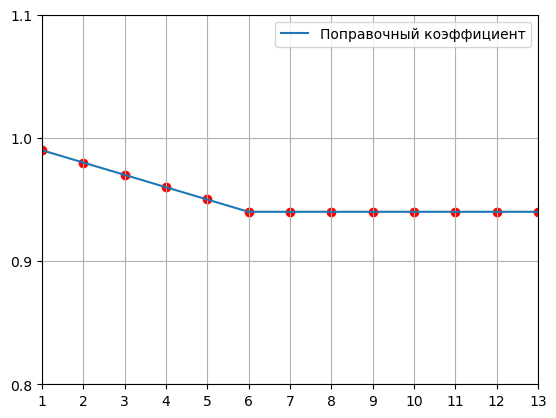

In [17]:
R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh_i = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_ад_полн_i, "Относительный КПД")
plot_results(N_list, Hт_i_отн, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh_i, "Поправочный коэффициент")

In [18]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
# Направление абсолютной скорости на входе в ВНА
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

# 3. Поступенчатый расчет значений для каждой ступени

In [19]:
# Коэффициент расхода на выходе из ступени
c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]]))

# Давление перед ступенями по длине компрессора
P1_полн_i = np.linspace(P1_полн, P2_полн, N)

# Температура перед ступенью по длине компрессора
T1_полн_i = np.linspace(T1_полн, T2_полн, N)

# Диаметры относительные по длине компрессора
d1_отн_i = np.linspace(d1_отн, d_n_отн, N)

# Окружные скорости по длине компрессора
U_k_i = np.linspace(U_k1, U_k2, N)

# Проверка: c_a не должна падать более чем на MAX_CA_DROP м/с между соседними ступенями
c_a_i_real = c_a_i_отн * U_k_i
if np.max(c_a_i_real[:-1] - c_a_i_real[1:]) > MAX_CA_DROP:
    print(f"Изменение скорости в ступени больше 12м/с")

# Начало расчета из Бекнева
# 1. Теоретический напор для i-й ступени:
Hт_i = Hт_i_отн * (U_k_i**2)

# 2. Действительная работа сжатия для i-й ступени:
L_z_i = Kh_i * Hт_i

# 3. Адиабатическая работа сжатия для i-й ступени:
H_ад_i = L_z_i * η_ад_полн_i

# Генерация c_p для каждой ступени через предзагруженную таблицу (Numba/Python fallback)
c_p_i = cp_lookup_array(P1_полн_i, T1_полн_i)
    
# 4. Повышение полной температуры в ступени:
ΔT_полн_i = L_z_i / c_p_i # с_р в каждой ступени разный т.к. меняется температура

# 5. Полная температура на выходе из ступени:
T3_полн_i = T1_полн_i + ΔT_полн_i
T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень

# 6. Степень повышения полного давления:
π_полн_i = (1 + (H_ад_i / (c_p_i * T1_полн_i)))**(k/(k-1))
   
# 7. Полное давление на выходе из ступени:
P3_полн_i = P1_полн_i * π_полн_i 
P1_полн_i_plus_1 = P3_полн_i
    
# 8. Критическая скорость потока на входе и выходе:
a_кр_1_i = np.sqrt((2*k/(k+1))*R_в*T1_полн_i)
a_кр_3_i = np.sqrt((2*k/(k+1))*R_в*T3_полн_i)
    
# 9. Средний радиус на входе в i-ю ступень:
r_ср1_отн_i = np.sqrt( (1 + d1_отн_i**2) / 2)
    
# 10. Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1) - (Hт_i_отн / (2 * r_ср1_отн_i))
    
# 11. Направление абсолютной скорости на входе
α_1_i = np.arctan(c_a_i_отн / c_u1_отн_i)
    
# 12. Приведенная скорость на входе
c_a1_i = c_a_i_отн * U_k_i
λ_1_i = c_a1_i / (np.sin(α_1_i) * a_кр_1_i)
    
# 13. ГДФ расхода
q_1_i = q_gdf(k, λ_1_i)

# 14. Кольцевая площадь на входе в ступень
F_1_i = (G_в * np.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * np.sin(α_1_i))

# 15. Кольцевая площадь на выходе из ступени F3
c_a3_отн_i = c_a_i_отн_plus_1
c_a3_i = c_a3_отн_i * U_k_i
λ_3_i_0 = c_a3_i / (np.sin(α_1_i) * a_кр_3_i)

q_3_i = q_gdf(k, λ_3_i_0)
F_3_i_0 = F_1_i * ((q_1_i * P1_полн_i) / (q_3_i * P3_полн_i)) * np.sqrt(T3_полн_i / T1_полн_i)
    
# 16. Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт3_i_0 = np.sqrt(D_к**2 - ((4 * F_3_i_0) / np.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d3_отн_i_0 = D_вт3_i_0 / D_к

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к3_i_0 = np.sqrt(D_вт**2 + ((4 * F_3_i_0)/ np.pi))
    d3_отн_i_0 = D_вт / D_к3_i_0

else:
    # Dср = const

    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i_0 / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i_0) / math.pi))
    d3_отн_i_0 = np.linspace(d1_отн, d1_отн, N)
    
# Относительный средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i_0**2) / 2)

# 17. Безразмерная окружная состовляющая абсолютной скорости на выходе
R_ср1_i_plus_1 = np.concatenate((R_ср1_list[1:], [R_ср1_list[-1]]))
Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [Hт_i_отн[-1]]))

c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_i_plus_1) - (Hт_i_отн / (2 * r_ср3_отн_i))

# 18. Направление потока в абсолютном движении после НА
α_3_i = np.atan(c_a3_отн_i / c_3u_отн_i)

# 19. Приведенная скорость на выходе
λ_3_i = c_a3_i / (np.sin(α_3_i) * a_кр_3_i)

# 20. Действительная кольцевая площадь на выходе из ступени
F_3_i = F_3_i_0 * ((q_gdf(k, λ_3_i_0)) / (q_gdf(k, λ_3_i)))
F_1_i_plus_1 = np.concatenate((F_3_i[1:], [F_3_i[-1]]))

# 21. Действительный относительный диаметр втулки d_3_отн подсчитывется в завис от типа проточн части.
if D_type == 'D_к_const':
    D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
    d3_отн_i = D_вт3_i / D_к1
        
    # Ограничение на высоту лопатки
    h_lopatki = D_к - D_вт3_i[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")

elif D_type == 'D_вт_const':
    D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
    d3_отн_i = D_вт / D_к3_i
    D_вт = D_вт1

    # Ограничение на высоту лопатки
    h_lopatki = D_к3_i[-1] - D_вт
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")
else:
    d3_отн_i = np.linspace(d1_отн, d1_отн, N)
    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i) / math.pi))

    # Ограничение на высоту лопатки
    h_lopatki = D_к_n[-1] - D_вт_n[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")    

# 22. Средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i**2) / 2)

# 23. Средний радиус на выходе из рабочего колеса
r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2

# 24. Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_i_отн + c_u1_отн_i * r_ср1_отн_i)

# 25. Углы потока в относительном движении
β_1_i = np.atan((c_a_i_отн / (r_ср1_отн_i- c_u1_отн_i)))
c_a2_отн_i = (c_a_i_отн + c_a_i_отн_plus_1) / 2
β_2_i = np.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
# 26. Направление потока в абсолютном движении после рабочего колеса
α_2_i = np.atan(c_a2_отн_i / c_u2_отн_i)
    
# 27. Углы поворота потока в средних сечениях лопаток РК и НА
ε_рк_i = β_2_i - β_1_i
ε_на_i = α_3_i - α_2_i

# 28. Относительная скорость на среднем радиусе на входе в РК
W_1_i = c_a1_i / np.sin(β_1_i)

# 29. Абсолютная скорость на среднем радиусе на входе в НА
c_a2_i = c_a2_отн_i * U_k_i
c_2_i = c_a2_i / np.sin(α_2_i)

# 30. Число Маха по относительной скорости на входе в РК
# ГДФ температуры на входе в РК
τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
# Статическая температура перед РК
T_1_i = T1_полн_i * τ_1_i
# Скорость звука на входе в РК
a_1_i = a_кр_def(k, R_в, T_1_i)

M_w1_i = W_1_i / a_1_i

# 31. Число Маха по абсолютной скорости на входе в НА
# Приведенная скорость перед НА
λ_c2_i = c_2_i / a_кр_3_i
# Статическая температура перед НА
T2_полн_i = T3_полн_i
τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
T_2_i = T2_полн * τ_2_i
# Скорость звука на входе в НА
a_2_i = a_кр_def(k, R_в, T_2_i)

M_c2_ср_i = c_2_i / a_2_i



# Надо перепроверить, нужно ли все, что ниже!!!!!!!!!!
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Абсолютная скорость на входе в РК
c_1_i = U_k_i * np.sqrt(c_a_i_отн**2 + c_u1_отн_i**2)
# Плотность заторможенного потока на выходе из ступени
ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
# Относительная скорость на среднем радиусе на входе в НА
W_2_i = c_a2_i / np.sin(β_2_i)

    
# Высота лопаток рабочего колеса
D_вт1_i = D_к * d1_отн_i
h_рк_i = 0.5 * (D_к - D_вт1_i)
    
# Относительный диаметр втулки на выходе из РК
d2_отн_i = np.sqrt(2 * (r_ср2_отн_i**2) - 1)
D_ср_1 = D_к * r_ср1_отн_i
D_ср_2 = D_к * r_ср2_отн_i
D_ср_3 = D_к * r_ср3_отн_i
    
# Периферийный диаметр на выходе из РК
D_вт2_i = D_к * d2_отн_i
D_вт1_i = D_к * d1_отн_i
    
# Высота лопаток НА
h_на_i = 0.5 * (D_к - D_вт2_i)
h_на_3_i = 0.5 * (D_к - D_вт3_i)

In [20]:
π_ла_полн = P2_полн / P1_полн
η_ла_полн = (T1_полн * (π_ла_полн**((k-1)/k) - 1)) / (T2_полн - T1_полн)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

π_к_полн = π_ла_полн * σ_вх * σ_вых

# Есть два варианта расчета кпд из учебника, будто 2 вариант круче
# !!!!!!!!!!!!!!!!!!!!!!!!!!
Tk_полн_new = T2_полн
T1_полн_new = Tа_полн

η_к_полн = np.sum(H_ад_i) / np.sum(L_z_i) - 0.02
N_к = G_в * np.sum(L_z_i)
print(f"""
π_ла_полн = {π_ла_полн}
η_ла_полн = {η_ла_полн}

π_ла_полн_0 = {π_ла_полн_0}
η_ла_полн_0 = {η_ла_полн_0}

π_к_полн = {π_к_полн:.4f}
η_к_полн = {η_к_полн:.4f}

π_к_полн_0 = {π_к_полн_0:.4f}
η_к_полн_0 = {η_к_полн_0:.4f}

N_к = {N_к}

N_stupeney = {N_stupeney}
""")


π_ла_полн = 18.472891949094397
η_ла_полн = 0.8401150594232466

π_ла_полн_0 = 18.437589592284773
η_ла_полн_0 = 0.8535838734561604

π_к_полн = 18.2000
η_к_полн = 0.8389

π_к_полн_0 = 18.2000
η_к_полн_0 = 0.8338

N_к = 16987514.29358319

N_stupeney = 13



In [21]:
# Список всех имён переменных‑списков
list_names = [
    "c_a_i_отн","c_a_i_отн_plus_1","P1_полн_i",
    "T1_полн_i","d1_отн_i","U_k_i","Hт_i","L_z_i","H_ад_i",
    "ΔT_полн_i","T3_полн_i","T1_полн_i_plus_1","π_полн_i",
    "P3_полн_i","P1_полн_i_plus_1","a_кр_1_i","a_кр_3_i",
    "r_ср1_отн_i","c_u1_отн_i","α_1_i","c_a1_i","λ_1_i",
    "q_1_i","F_1_i","c_a3_отн_i","c_a3_i","λ_3_i_0","q_3_i",
    "F_3_i_0","d3_отн_i_0","r_ср3_отн_i","c_3u_отн_i","α_3_i",
    "λ_3_i","F_3_i","F_1_i_plus_1","d3_отн_i","r_ср2_отн_i",
    "c_u2_отн_i","β_1_i","c_a2_отн_i","β_2_i","α_2_i","ε_рк_i",
    "ε_на_i","W_1_i","c_a2_i","c_2_i","τ_1_i","T_1_i","a_1_i",
    "M_w1_i","λ_c2_i","T2_полн_i","τ_2_i","T_2_i","a_2_i","M_c2_ср_i"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
"""
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))
"""
# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,c_a_i_отн,c_a_i_отн_plus_1,P1_полн,T1_полн,d1_отн,U_k,Hт,L_z,H_ад,ΔT_полн,T3_полн,T1_полн_i_plus_1,π_полн,P3_полн,P1_полн_i_plus_1,a_кр_1,a_кр_3,r_ср1_отн,c_u1_отн,α_1,c_a1,λ_1,q_1,F_1,c_a3_отн,c_a3,λ_3_i_0,q_3,F_3_i_0,d3_отн_i_0,r_ср3_отн,c_3u_отн,α_3,λ_3,F_3,F_1_i_plus_1,d3_отн,r_ср2_отн,c_u2_отн,β_1,c_a2_отн,β_2,α_2,ε_рк,ε_на,W_1,c_a2,c_2,τ_1,T_1,a_1,M_w1,λ_c2,T2_полн,τ_2,T_2,a_2,M_c2_ср
0,0.7,0.6717,1.002e+05,288,0.4,299.3,1.194e+04,1.182e+04,9111,11.75,299.8,299.8,1.114,1.117e+05,1.117e+05,310.8,317,0.7616,0.2932,1.174,209.5,0.7309,0.9132,0.2922,0.6717,201,0.6875,0.8833,0.2765,0.4504,0.7771,0.3018,1.148,0.6951,0.2748,0.1221,0.456,0.7694,0.4636,0.9812,0.6858,1.151,0.9764,0.1703,0.1721,252.1,205.3,247.7,0.911,262.4,296.6,0.8498,0.7815,299.8,0.8982,659.2,470.1,0.527
1,0.6717,0.6433,2.461e+05,325.2,0.442,299.1,1.44e+04,1.411e+04,1.125e+04,13.97,339.1,339.1,1.125,2.769e+05,2.769e+05,330.2,337.2,0.7731,0.2824,1.173,200.9,0.6601,0.8624,0.1339,0.6433,192.4,0.6191,0.828,0.1266,0.7969,0.9077,0.3631,1.057,0.6553,0.1221,0.08528,0.805,0.8404,0.4514,0.9399,0.6575,1.036,0.9692,0.09659,0.0878,248.8,196.7,238.5,0.9274,301.5,318,0.7825,0.7074,339.1,0.9166,672.7,474.9,0.5023
2,0.6433,0.615,3.92e+05,362.3,0.484,299,1.665e+04,1.615e+04,1.326e+04,15.91,378.2,378.2,1.132,4.438e+05,4.438e+05,348.5,356.1,0.7856,0.2742,1.168,192.3,0.5998,0.8107,0.09462,0.615,183.9,0.5612,0.7736,0.08949,0.8614,0.9365,0.3668,1.033,0.6011,0.08528,0.06941,0.8684,0.8611,0.4666,0.8992,0.6292,1.011,0.9327,0.1116,0.1003,245.7,188.1,234.2,0.94,340.6,337.9,0.727,0.6576,378.2,0.9279,681,477.9,0.49
3,0.615,0.5867,5.379e+05,399.5,0.526,298.8,1.875e+04,1.8e+04,1.514e+04,17.7,417.2,417.2,1.137,6.115e+05,6.115e+05,366,374,0.799,0.2681,1.16,183.8,0.5477,0.76,0.0775,0.5867,175.3,0.5113,0.7215,0.0734,0.8879,0.9487,0.3618,1.018,0.5506,0.06941,0.06113,0.8944,0.8738,0.4854,0.8587,0.6008,0.9969,0.8912,0.1383,0.127,242.8,179.5,230.8,0.95,379.5,356.7,0.6805,0.6171,417.2,0.9365,687.3,480.1,0.4808
4,0.5867,0.5583,6.839e+05,436.6,0.5681,298.6,2.072e+04,1.968e+04,1.689e+04,19.25,455.9,455.9,1.139,7.788e+05,7.788e+05,382.6,391,0.8132,0.2638,1.148,175.2,0.502,0.7114,0.06845,0.5583,166.7,0.4676,0.6722,0.06499,0.9015,0.9549,0.354,1.006,0.505,0.06113,0.05653,0.9076,0.8841,0.5054,0.8182,0.5725,0.9864,0.8476,0.1683,0.1582,240,171,228.1,0.958,418.3,374.5,0.6409,0.5833,455.9,0.9433,692.3,481.8,0.4733
5,0.5583,0.53,8.298e+05,473.8,0.6101,298.5,2.258e+04,2.123e+04,1.851e+04,20.63,494.4,494.4,1.139,9.454e+05,9.454e+05,398.6,407.2,0.8283,0.2611,1.133,166.6,0.4616,0.6652,0.06327,0.53,158.2,0.4289,0.6259,0.06029,0.909,0.9584,0.3451,0.9936,0.4636,0.05653,0.054,0.9149,0.8934,0.5259,0.7775,0.5442,0.9768,0.8025,0.1993,0.1911,237.5,162.4,225.9,0.9645,457,391.4,0.6068,0.5547,494.4,0.9487,696.3,483.2,0.4675
6,0.53,0.5017,9.757e+05,511,0.6521,298.3,2.436e+04,2.29e+04,2.017e+04,22.1,533,533,1.14,1.112e+06,1.112e+06,413.9,422.8,0.8442,0.2599,1.115,158.1,0.4254,0.6216,0.06033,0.5017,149.6,0.3943,0.5824,0.0577,0.9131,0.9603,0.3358,0.9809,0.426,0.054,0.05292,0.9189,0.9022,0.5466,0.7368,0.5158,0.9672,0.7564,0.2304,0.2245,235.3,153.9,224.2,0.9698,495.5,407.6,0.5772,0.5303,533,0.9531,699.5,484.3,0.4629
7,0.5017,0.4733,1.122e+06,548.1,0.6941,298.1,2.603e+04,2.447e+04,2.169e+04,23.45,571.6,571.6,1.139,1.278e+06,1.278e+06,428.7,437.8,0.8607,0.2602,1.092,149.6,0.393,0.5808,0.05884,0.4733,141.1,0.3631,0.5419,0.05654,0.9149,0.9611,0.3264,0.9671,0.3916,0.05292,0.05294,0.9206,0.9109,0.5674,0.6959,0.4875,0.957,0.7098,0.261,0.2574,233.3,145.3,223,0.9743,534,423.1,0.5513,0.5095,571.6,0.9567,702.2,485.2,0.4597
8,0.4733,0.445,1.268e+06,585.3,0.7361,298,2.76e+04,2.594e+04,2.301e+04,24.64,609.9,609.9,1.137,1.441e+06,1.441e+06,443,452.2,0.878,0.262,1.065,141,0.3639,0.5429,0.0584,0.445,132.6,0.3351,0.5043,0.05645,0.915,0.9611,0.3171,0.9517,0.36,0.05294,0.05391,0.9205,0.9196,0.5882,0.6552,0.4592,0.9457,0.6628,0.2905,0.2889,231.5,136.8,222.3,0.9779,572.4,438.1,0.5284,0.4917,609.9,0.9597,704.3,486,0.4575
9,0.445,0.4167,1.413e+06,622.4,0.7781

# 5. Расчет ступеней по высоте лопаток

In [22]:
# Втулочное сечение:
U_вт_1_i = U_k_i * d1_отн_i
U_вт_2_i = U_k_i * d2_отн_i

c_1u_вт_i = U_вт_1_i * c_u1_отн_i * (D_ср_1 / D_вт1_i)
c_2u_вт_i = U_вт_2_i * c_u2_отн_i * (D_ср_2 / D_вт2_i)
c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], c_1u_вт_i[-1:]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_вт_i = c_a1_i
c_a2_вт_i = c_a2_i
c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], c_a1_вт_i[-1:]])

c_1_вт_i = np.sqrt(((c_a1_вт_i)**2) + ((c_1u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a2_вт_i)**2) + ((c_2u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a3_вт_i)**2) + ((c_3u_вт_i)**2))

α_1_вт_i = np.atan(c_a1_вт_i / c_1u_вт_i)
α_2_вт_i = np.atan(c_a2_вт_i / c_2u_вт_i)
α_3_вт_i = np.atan(c_a3_вт_i / c_3u_вт_i)

β_1_вт_i = np.atan(c_a1_вт_i / (U_вт_1_i - c_1u_вт_i))
β_2_вт_i = np.atan(c_a2_вт_i / (U_вт_2_i - c_2u_вт_i))

ε_вт_рк_i = β_2_вт_i - β_1_вт_i
ε_вт_на_i = α_3_вт_i - α_2_вт_i

In [23]:
# Периферийное сечение:
U_к_1_i = U_k_i
U_к_2_i = U_k_i

D_к1_i = np.full(len(U_k_i), D_к1)
D_к2_i = np.full(len(U_k_i), D_к1)

c_1u_к_i = U_к_1_i * c_u1_отн_i * (D_ср_1 / D_к1_i)
c_2u_к_i = U_к_2_i * c_u2_отн_i * (D_ср_2 / D_к2_i)
c_3u_к_i = np.concatenate([c_1u_к_i[1:], c_1u_к_i[-1:]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_к_i = c_a1_i
c_a2_к_i = c_a2_i
c_a3_к_i = np.concatenate([c_a1_к_i[1:], c_a1_к_i[-1:]])

c_1_к_i = np.sqrt(((c_a1_к_i)**2) + ((c_1u_к_i)**2))
c_1_к_i = np.sqrt(((c_a2_к_i)**2) + ((c_2u_к_i)**2))
c_1_к_i = np.sqrt(((c_a3_к_i)**2) + ((c_3u_к_i)**2))

α_1_к_i = np.atan(c_a1_к_i / c_1u_к_i)
α_2_к_i = np.atan(c_a2_к_i / c_2u_к_i)
α_3_к_i = np.atan(c_a3_к_i / c_3u_к_i)

β_1_к_i = np.atan(c_a1_к_i / (U_к_1_i - c_1u_к_i))
β_2_к_i = np.atan(c_a2_к_i / (U_к_2_i - c_2u_к_i))

ε_к_рк_i = β_2_к_i - β_1_к_i
ε_к_на_i = α_3_к_i - α_2_к_i

W_1к_i = c_a1_к_i / (np.sin(β_1_к_i))
W_1вт_i = c_a1_вт_i / (np.sin(β_1_вт_i))

W_2к_i = c_a2_к_i / (np.sin(β_2_к_i))
W_2вт_i = c_a2_вт_i / (np.sin(β_2_вт_i))

a_1к_i = np.sqrt(k * R_в * T_1_i)
M_w1к_i = W_1к_i / a_1к_i

λ_w1к_i = W_1к_i / a_кр_1_i
λ_w1_i = W_1_i / a_кр_1_i
λ_w1вт_i = W_1вт_i / a_кр_1_i

In [24]:
list_names = [
    "U_вт_1_i","U_вт_2_i",
    "c_1u_вт_i","c_2u_вт_i","c_3u_вт_i",
    "U_1_ср_i","U_k2_i","U_2_ср_i",
    "c_a1_вт_i","c_a2_вт_i","c_a3_вт_i",
    "c_1_вт_i",
    "α_1_вт_i","α_2_вт_i","α_3_вт_i",
    "β_1_вт_i","β_2_вт_i",
    "ε_вт_рк_i","ε_вт_на_i",

    "U_к_1_i","U_к_2_i",
    "D_к1_i","D_к2_i",
    "c_1u_к_i","c_2u_к_i","c_3u_к_i",
    "c_a1_к_i","c_a2_к_i","c_a3_к_i",
    "c_1_к_i",
    "α_1_к_i","α_2_к_i","α_3_к_i",
    "β_1_к_i","β_2_к_i",
    "ε_к_рк_i","ε_к_на_i",

    "W_1к_i","W_1вт_i",
    "W_2к_i","W_2вт_i",
    "a_1к_i","M_w1к_i",
    "λ_w1к_i","λ_w1_i","λ_w1вт_i"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))

# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
# df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,U_вт_1,U_вт_2,c_1u_вт,c_2u_вт,c_3u_вт,U_1_ср,U_k2,U_2_ср,c_a1_вт,c_a2_вт,c_a3_вт,c_1_вт,α_1_вт,α_2_вт,α_3_вт,β_1_вт,β_2_вт,ε_вт_рк,ε_вт_на,U_к_1,U_к_2,D_к1,D_к2,c_1u_к,c_2u_к,c_3u_к,c_a1_к,c_a2_к,c_a3_к,c_1_к,α_1_к,α_2_к,α_3_к,β_1_к,β_2_к,ε_к_рк,ε_к_на,W_1к,W_1вт,W_2к,W_2вт,a_1к,M_w1к,λ_w1к,λ_w1,λ_w1вт
0,119.7,128.3,66.84,106.7,65.31,227.9,299.3,230.3,209.5,205.3,200.9,211.3,1.262,1.091,1.256,1.324,1.466,0.1425,0.1652,299.3,299.3,0.6646,0.6646,66.84,106.7,65.31,209.5,205.3,200.9,211.3,1.262,1.091,1.256,0.7335,0.8174,0.08384,0.1652,312.9,216.1,281.4,206.4,324.9,0.9631,1.007,0.8111,0.6953
1,132.2,192.1,65.31,113.5,64.39,231.2,299.3,251.5,200.9,196.7,192.3,202.8,1.256,1.048,1.248,1.249,1.19,-0.0591,0.2002,299.1,299.1,0.6646,0.6646,65.31,113.5,64.39,200.9,196.7,192.3,202.8,1.256,1.048,1.248,0.7099,0.8142,0.1043,0.2002,308.3,211.8,270.5,211.8,348.3,0.885,0.9336,0.7535,0.6413
2,144.7,207.7,64.39,120.1,64,234.9,299.3,257.7,192.3,188.1,183.8,194.6,1.248,1.003,1.236,1.175,1.135,-0.04044,0.2331,299,299,0.6646,0.6646,64.39,120.1,64,192.3,188.1,183.8,194.6,1.248,1.003,1.236,0.6868,0.8106,0.1238,0.2331,303.3,208.4,259.5,207.5,370.2,0.8194,0.8703,0.7049,0.598
3,157.2,216.9,64,126.7,64.06,238.7,299.3,261.5,183.8,179.5,175.2,186.5,1.236,0.9561,1.22,1.101,1.105,0.003735,0.2642,298.8,298.8,0.6646,0.6646,64,126.7,64.06,183.8,179.5,175.2,186.5,1.236,0.9561,1.22,0.6641,0.8067,0.1426,0.2642,298.2,206,248.7,200.9,390.8,0.763,0.8147,0.6633,0.5629
4,169.6,224.1,64.06,133.4,64.55,242.9,299.3,264.6,175.2,171,166.6,178.7,1.22,0.9081,1.201,1.028,1.083,0.05468,0.2931,298.6,298.6,0.6646,0.6646,64.06,133.4,64.55,175.2,171,166.6,178.7,1.22,0.9081,1.201,0.6415,0.8026,0.1611,0.2931,292.8,204.5,237.7,193.5,410.2,0.7136,0.7652,0.6273,0.5346
5,182.1,230.4,64.55,140.2,65.46,247.2,299.3,267.4,166.6,162.4,158.1,171.1,1.201,0.8586,1.178,0.9565,1.064,0.1072,0.3196,298.5,298.5,0.6646,0.6646,64.55,140.2,65.46,166.6,162.4,158.1,171.1,1.201,0.8586,1.178,0.619,0.7984,0.1794,0.3196,287.2,203.9,226.8,185.8,428.8,0.6698,0.7206,0.596,0.5116
6,194.5,236.4,65.46,147.1,66.78,251.8,299.3,270,158.1,153.9,149.6,163.8,1.178,0.8079,1.151,0.8862,1.045,0.1588,0.343,298.3,298.3,0.6646,0.6646,65.46,147.1,66.78,158.1,153.9,149.6,163.8,1.178,0.8079,1.151,0.5965,0.7942,0.1977,0.343,281.4,204.1,215.7,177.9,446.5,0.6303,0.68,0.5685,0.4931
7,206.9,242.1,66.78,154.1,68.55,256.6,299.3,272.6,149.6,145.3,141,156.8,1.151,0.7561,1.118,0.8179,1.026,0.2084,0.3623,298.1,298.1,0.6646,0.6646,66.78,154.1,68.55,149.6,145.3,141,156.8,1.151,0.7561,1.118,0.5739,0.7899,0.216,0.3623,275.5,205,204.6,169.9,463.5,0.5943,0.6426,0.5442,0.4781
8,219.3,247.7,68.55,161.2,70.81,261.6,299.3,275.2,141,136.8,132.5,150.3,1.118,0.7039,1.08,0.752,1.007,0.2547,0.3762,298,298,0.6646,0.6646,68.55,161.2,70.81,141,136.8,132.5,150.3,1.118,0.7039,1.08,0.5512,0.7855,0.2343,0.3762,269.3,206.5,193.5,161.9,479.9,0.5612,0.6079,0.5226,0.4661
9,231.7,253.2,70.81,168.3,73.64,266.8,299.3,277.8,132.5,128.3,124,144.2,1.08,0.6515,1.035,0.6889,0.9859,0.2969,0.3834,297.8,297.8,0.6646,0.6646,70.81,168.3,73.64,132.5,128.3,124,144.2,1.08,0.6515,1.035,0.5284,0.7805,0.2521,0.3834,262.9,208.5,182.3,153.9,495.7,0.5303,0.5754,0.5031,0.4563


# 4. Профилирование решеток

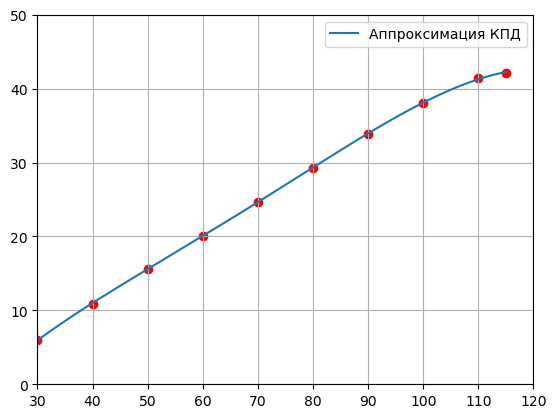

In [25]:
# График с учебника рис. 4

# Точки
β_2_dots = np.array([30, 40, 50, 60, 70, 80, 90, 100, 110, 115])       # точки по оси X для теоретического напора
ε_b_ε_dots = np.array([6, 10.85, 15.65, 20.1, 24.71, 29.31, 33.8, 38.1, 41.5, 42.1])      # точки по оси Y для теоретического напора

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(β_2_dots, ε_b_ε_dots, stepen)
poly = np.poly1d(coeffs)

smoothness = 100000     # Число точек

β_2_dots_smooth = np.linspace(min(β_2_dots), max(β_2_dots), smoothness)
ε_b_ε_dots_smooth = poly(β_2_dots_smooth)

plt.plot(β_2_dots_smooth, ε_b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(β_2_dots, ε_b_ε_dots, color="red")
plt.xlim(30,120)
plt.ylim(0, 50)
plt.xticks(np.arange(30, 130, 10))  # Установка делений по оси X с шагом 10
plt.yticks(np.arange(0, 60, 10))  # Установка делений по оси Y с шагом 10
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

ε_1_x_line = β_2_dots_smooth
ε_1_y_line = ε_b_ε_dots_smooth

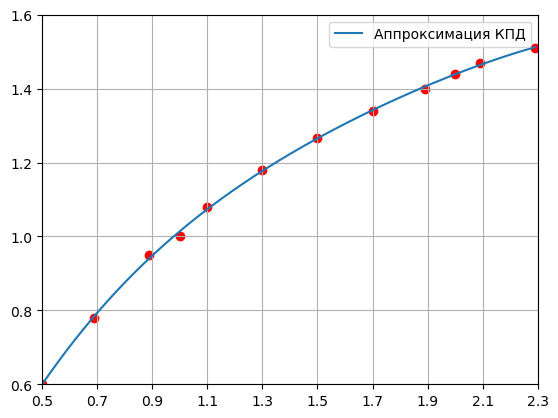

In [26]:
# График с учебника рис. 4

# Точки
b_t_dots = np.array([0.5, 0.69, 0.89, 1.0, 1.1, 1.3, 1.5, 1.7, 1.89, 2.0, 2.09, 2.29])       # точки по оси X для теоретического напора
ε__b_ε_dots = np.array([0.6, 0.78, 0.95, 1.0, 1.08, 1.18, 1.265, 1.34, 1.4, 1.44, 1.47, 1.51])      # точки по оси Y для теоретического напора

#b_t_dots = np.array([0.5, 1.0, 1.5,2.0, 2.29])       # точки по оси X для теоретического напора
#ε__b_ε_dots = np.array([0.6, 1.0, 1.265, 1.44, 1.51])      # точки по оси Y для теоретического напора


# аппроксимация полиномом степени stepen
stepen = 4
coeffs1 = np.polyfit(b_t_dots, ε__b_ε_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек

b_t_dots_smooth = np.linspace(min(b_t_dots), max(b_t_dots), smoothness)
ε__b_ε_dots_smooth = poly1(b_t_dots_smooth)

plt.plot(b_t_dots_smooth, ε__b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(b_t_dots, ε__b_ε_dots, color="red")
plt.xlim(0.5,2.3)
plt.ylim(0.6, 1.6)
plt.xticks(np.arange(0.5, 2.4, 0.2))  # Установка делений по оси X с шагом 0.2
plt.yticks(np.arange(0.6, 1.7, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

ε_отн_x_line = b_t_dots_smooth
ε_отн_y_line = ε__b_ε_dots_smooth

In [27]:
# Рабочее колесо
ε_РК_x, ε_РК_i= find_nearest(β_2_i, ε_1_x_line, ε_1_y_line)
b_1_x, b_1_i= find_nearest((ε_рк_i / ε_РК_i), ε_отн_x_line, ε_отн_y_line)

# Направляющий аппарат
ε_НА_x, ε_НА_i= find_nearest(α_3_i, ε_1_x_line, ε_1_y_line)
b_2_x, b_2_i= find_nearest((ε_на_i / ε_НА_i), ε_отн_x_line, ε_отн_y_line)

# Углы атаки
i_рк_i = 2.5 * (b_1_i - 1)  # Угол атаки для РК. Тут умножается на deg
i_на_i = 2.5 * (b_2_i - 2)  # Угол атаки для РК

# Коэффициент учитывающий форму средней линии дуги профиля
X_f_отн = 0.5   #  Может быть 0.45 для параболической формы
m_рк_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * β_2_i # Тут делится на deg
m_на_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * α_3_i

θ_рк_i = ((ε_рк_i - i_рк_i) / (1 - m_рк_i * np.sqrt(1 / b_1_i)))
θ_на_i = ((ε_на_i - i_на_i) / (1 - m_на_i * np.sqrt(1 / b_2_i)))

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_i = 0.5 * θ_рк_i
    χ_на_i = 0.5 * θ_на_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_i = 0.6 * θ_рк_i
    χ_на_i = 0.6 * θ_на_i

v_рк_i = χ_рк_i + β_1_i + i_рк_i
v_на_i = χ_на_i + α_2_i + i_на_i